In [4]:
# Install if needed
# pip install scanpy

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
import pandas as pd
import scanpy as sc

# ==========================
# LOAD DATA
# ==========================
control_df = pd.read_csv("scRNA_control_data.csv", index_col=0)
disease_df = pd.read_csv("scRNA_disease_data.csv", index_col=0)

# ==========================
# CLEAN FUNCTION
# ==========================
def clean_dataframe(df):
    # Ensure gene names are strings
    df.index = df.index.astype(str)

    # Remove duplicate genes
    df = df[~df.index.duplicated()]

    # Ensure cell names are strings
    df.columns = df.columns.astype(str)

    return df

# Apply cleaning
control_df = clean_dataframe(control_df)
disease_df = clean_dataframe(disease_df)

# ==========================
# CONVERT TO AnnData
# ==========================
adata_control = sc.AnnData(control_df.T)
adata_disease = sc.AnnData(disease_df.T)

# ==========================
# ADD METADATA
# ==========================
adata_control.obs["condition"] = "control"
adata_disease.obs["condition"] = "disease"

# ==========================
# MAKE GENE NAMES CONSISTENT
# ==========================
# Keep only common genes
common_genes = adata_control.var_names.intersection(adata_disease.var_names)

adata_control = adata_control[:, common_genes]
adata_disease = adata_disease[:, common_genes]

# ==========================
# COMBINE DATASETS
# ==========================
adata = adata_control.concatenate(
    adata_disease,
    batch_key="dataset",
    batch_categories=["control", "disease"]
)

# ==========================
# FINAL CHECK
# ==========================
print(adata)
print(adata.obs['condition'].value_counts())

C:\Users\Thila\AppData\Local\Temp\ipykernel_20448\283269698.py:53: FutureWarning: The method concatenate is deprecated and will be removed in the future. Use anndata.concat instead of AnnData.concatenate. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_control.concatenate(


AnnData object with n_obs × n_vars = 2922 × 6739
    obs: 'condition', 'dataset'
condition
control    1585
disease    1337
Name: count, dtype: int64


In [70]:
#QC

In [71]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

# ==========================
# MANUAL QC METRICS
# ==========================

import numpy as np

# Total counts per cell
adata.obs["total_counts"] = np.sum(adata.X, axis=1)

# Number of genes detected per cell
adata.obs["n_genes_by_counts"] = np.sum(adata.X > 0, axis=1)

C:\Users\Thila\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


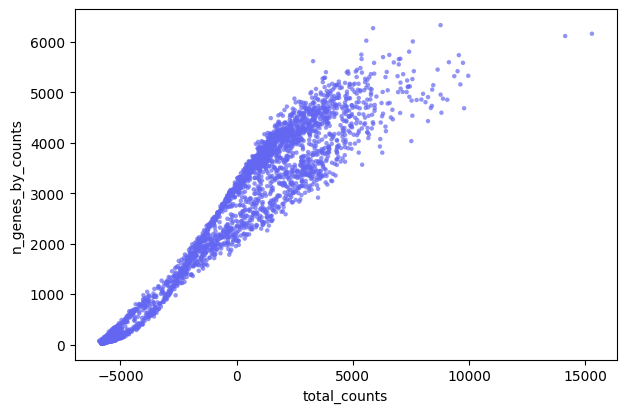

In [72]:
import scanpy as sc

sc.pl.scatter(
    adata,
    x='total_counts',
    y='n_genes_by_counts',
    color='#6366F1',   # modern indigo
    alpha=0.7
)


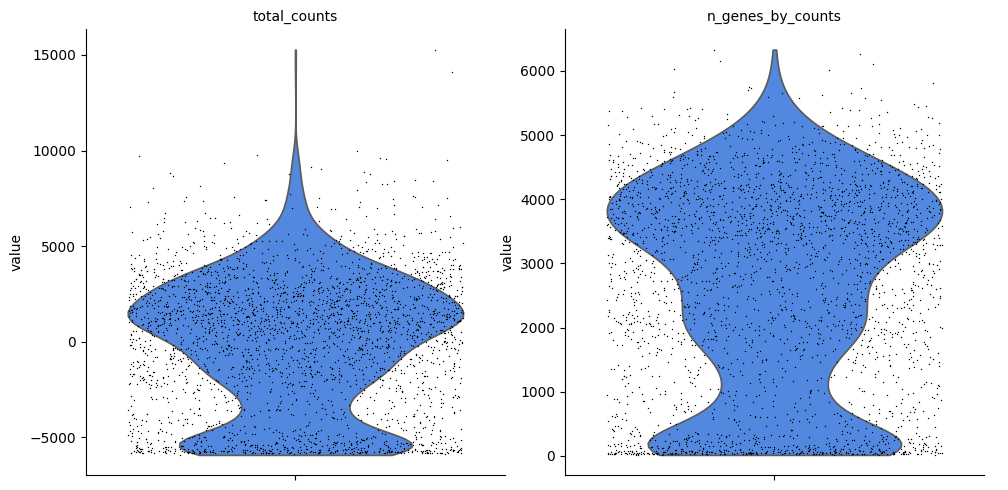

In [73]:
sc.pl.violin(
    adata,
    ['total_counts', 'n_genes_by_counts'],
    jitter=0.4,
    multi_panel=True,
    color="#3B82F6"   # single color only
)

In [74]:
#STEP 1 - Filtering Cells and Genes

In [75]:
before_shape = adata.shape
print("Before filtering:", before_shape)

Before filtering: (2922, 6739)


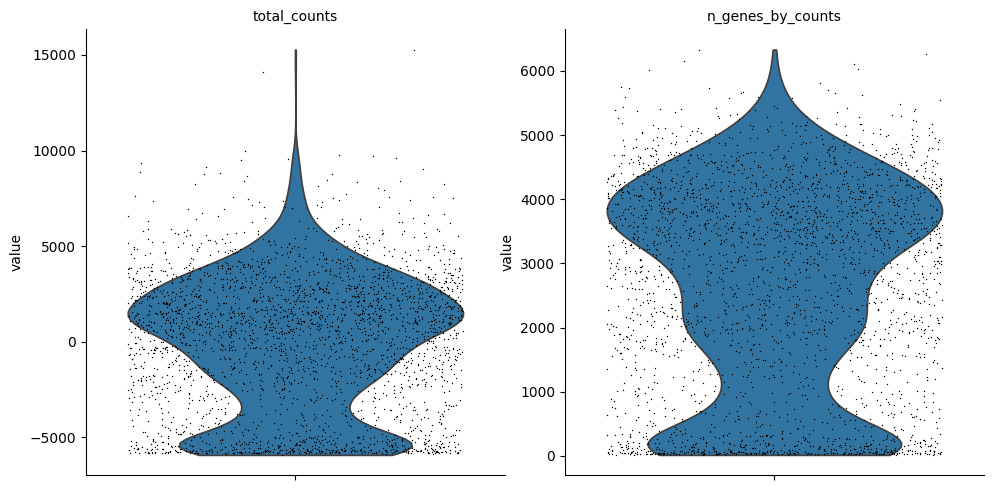

In [76]:
import scanpy as sc

sc.pl.violin(
    adata,
    ['total_counts', 'n_genes_by_counts'],
    jitter=0.4,
    multi_panel=True
)

In [77]:
sc.pp.filter_cells(adata, min_genes=200)

In [78]:
sc.pp.filter_genes(adata, min_cells=3)

In [79]:
adata = adata[adata.obs['total_counts'] > 1000, :]

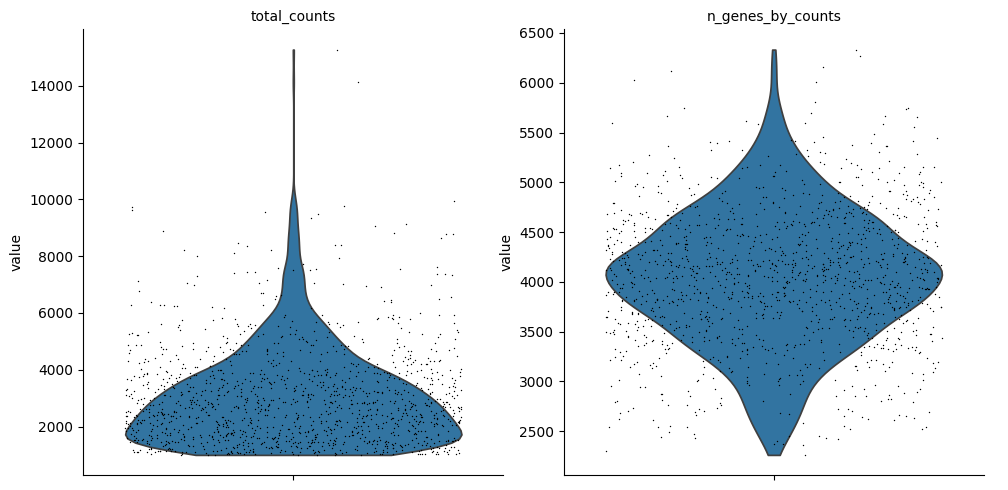

In [80]:
sc.pl.violin(
    adata,
    ['total_counts', 'n_genes_by_counts'],
    jitter=0.4,
    multi_panel=True
)

In [81]:
print("After filtering:")
print(adata.shape)

After filtering:
(1316, 6739)


In [110]:
# Before 2922 × 6739
# After (1316, 6739)
before = 2922
after = 1316

removed_pct = (before - after) / before * 100
print(f"Cells removed: {removed_pct:.2f}%")

Cells removed: 54.96%


In [83]:
# STEP 2 – Normalization

In [84]:
sc.pp.normalize_total(adata, target_sum=1e4)

C:\Users\Thila\AppData\Local\Temp\ipykernel_20448\3661531845.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


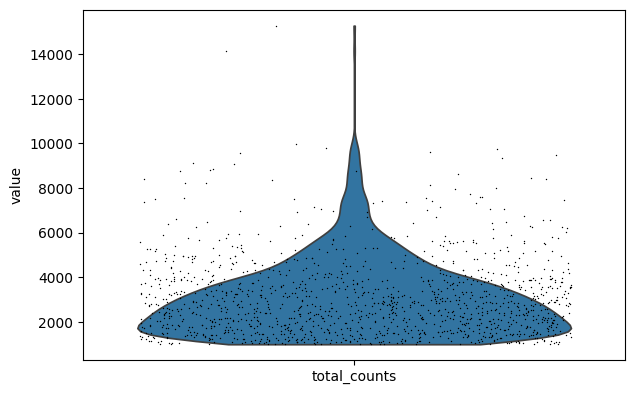

In [98]:
sc.pl.violin(
    adata,
    ['total_counts'],
    jitter=0.4
)

In [99]:
#lOG TRANSFORMATION

In [100]:
sc.pp.log1p(adata)

C:\Users\Thila\AppData\Local\Programs\Python\Python313\Lib\site-packages\scanpy\preprocessing\_simple.py:377: RuntimeWarning: invalid value encountered in log1p
  np.log1p(x, out=x)


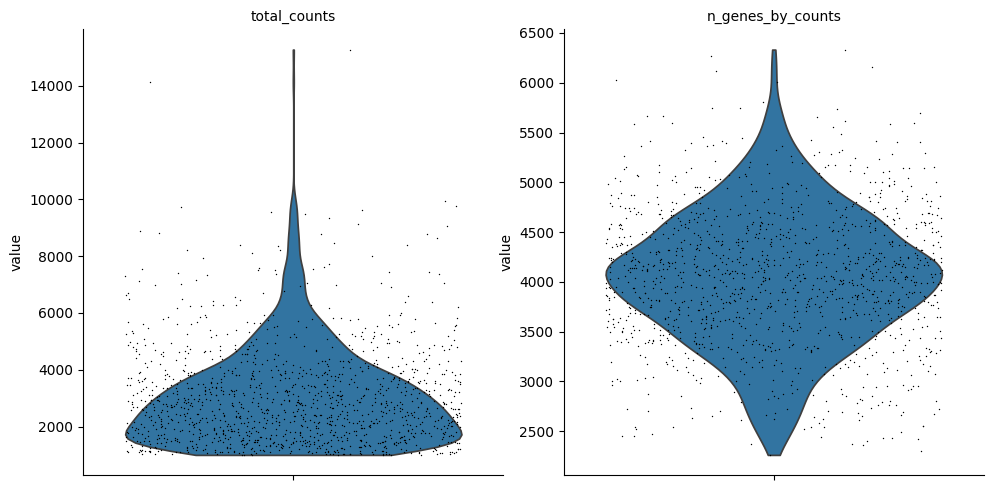

In [101]:
sc.pl.violin(
    adata,
    ['total_counts', 'n_genes_by_counts'],
    jitter=0.4,
    multi_panel=True
)

In [102]:
#3. Identify Highly Variable Genes (HVGs)

In [103]:
import numpy as np

# ==========================
# REMOVE INVALID VALUES
# ==========================

# Replace inf / -inf with 0
adata.X[np.isinf(adata.X)] = 0

# Replace NaN with 0
adata.X = np.nan_to_num(adata.X)

# ==========================
# REMOVE ALL-ZERO GENES
# ==========================

gene_sums = np.sum(adata.X, axis=0)
adata = adata[:, gene_sums > 0]

In [104]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,   # safer than min_mean/max_mean
    flavor="seurat"
)

C:\Users\Thila\AppData\Local\Programs\Python\Python313\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:805: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


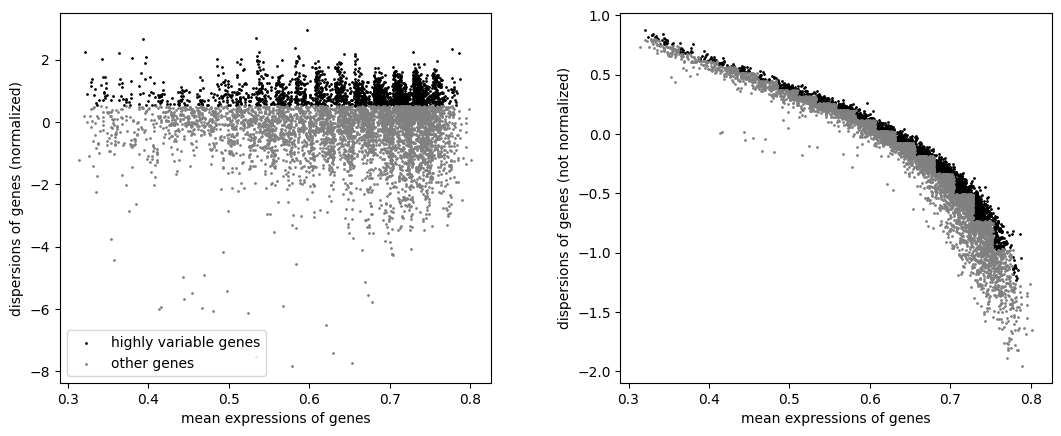

In [105]:
sc.pl.highly_variable_genes(adata)

In [106]:
# ==========================
# SAVE EXPRESSION MATRIX
# ==========================
df_processed = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=adata.var_names
)

df_processed.to_csv("processed_hvg_data.csv")

# ==========================
# SAVE METADATA
# ==========================
adata.obs.to_csv("cell_metadata.csv")
adata.var.to_csv("gene_metadata.csv")

In [107]:
import pandas as pd

df_processed = pd.read_csv("processed_hvg_data.csv", index_col=0)

print(df_processed.shape)
df_processed.head()

(1316, 6389)


,14.6712184029,1.74042870544,22.2500553962,97.4804682609,2.24594321301,54.4367747658,221.391090817,16.3913782496,99.8226880307,1.55889947244,...,259.782247442,39.2127077231,2661.05547583,257.235362663,139.745569254,690.97152082,532.211095165,52.8049131567,248.937447739,10.718140111
HP1502401_A14-control,0.0,1.096620,1.200525,0.000000,-0.773527,0.00000,1.109886,1.200687,0.000000,0.000000,...,1.028539,1.064532,0.776959,1.028209,0.000000,0.650231,0.729994,1.087956,0.786411,-0.078836
HP1502401_L14-control,0.0,0.000000,0.000000,1.109388,0.000000,0.00000,0.000000,0.778220,0.996763,0.716269,...,1.117183,1.033945,1.024510,0.824929,1.226130,1.025986,1.070223,1.063698,0.000000,0.000000
HP1502401_M14-control,0.0,0.940947,0.000000,0.000000,1.200639,1.10711,0.964184,0.000000,0.000000,0.000000,...,0.995341,1.033143,0.923965,1.058998,0.000000,0.940442,0.974277,0.990018,1.005763,-0.038822
HP1502401_K14-control,0.0,0.000000,1.141802,0.000000,0.000000,0.00000,0.000000,1.217272,0.000000,1.086100,...,1.136171,1.044678,1.050999,0.965492,1.210675,1.055331,1.056518,0.000000,0.000000,-0.058557
HP1502401_I14-control,0.0,0.919821,0.961783,0.000000,0.995213,0.00000,0.897320,0.890418,0.739241,0.000000,...,0.745409,0.865309,0.781042,0.790453,0.000000,0.731326,0.759819,0.869442,0.892054,-0.026381


In [108]:
cell_metadata = pd.read_csv("cell_metadata.csv", index_col=0)

print(cell_metadata.shape)
cell_metadata.head()

(1316, 11)


,condition,dataset,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes
HP1502401_A14-control,control,control,3345,8.815815,1822.253358,7.508378,9.941461,17.448532,30.595158,63.510004,3345
HP1502401_L14-control,control,control,3192,8.815815,2378.778949,7.774763,9.753895,16.985961,29.441919,59.861524,3192
HP1502401_M14-control,control,control,3440,8.815815,3560.742931,8.178005,7.719413,12.820389,21.836857,44.385471,3440
HP1502401_K14-control,control,control,3010,8.815815,2406.206280,7.786222,10.024283,17.339987,30.242161,62.209055,3010
HP1502401_I14-control,control,control,4151,8.815815,5176.531520,8.552084,4.392797,7.709942,13.548082,28.502213,4151


In [109]:
gene_metadata = pd.read_csv("gene_metadata.csv", index_col=0)

print(gene_metadata.shape)
gene_metadata.head()

(6389, 11)


,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
Gene,,,,,,,,,,,
14.671218,2922,7.732806e-16,7.732806e-16,0.0,2.259526e-12,2.259526e-12,439,True,0.346421,0.765134,0.822373
1.740429,2922,-6.808760e-16,-6.808760e-16,0.0,-1.989520e-12,-1.989520e-12,830,False,0.556927,0.223920,-0.252561
22.250055,2922,-4.153344e-15,-4.153344e-15,0.0,-1.213607e-11,-1.213607e-11,1123,False,0.651141,-0.132055,-0.352128
97.480468,2922,-3.297385e-15,-3.297385e-15,0.0,-9.634959e-12,-9.634959e-12,1111,True,0.656972,-0.021071,2.186125
2.245943,2922,-1.964814e-15,-1.964814e-15,0.0,-5.741185e-12,-5.741185e-12,799,False,0.550624,0.249952,0.322793


In [111]:
#Visualizations

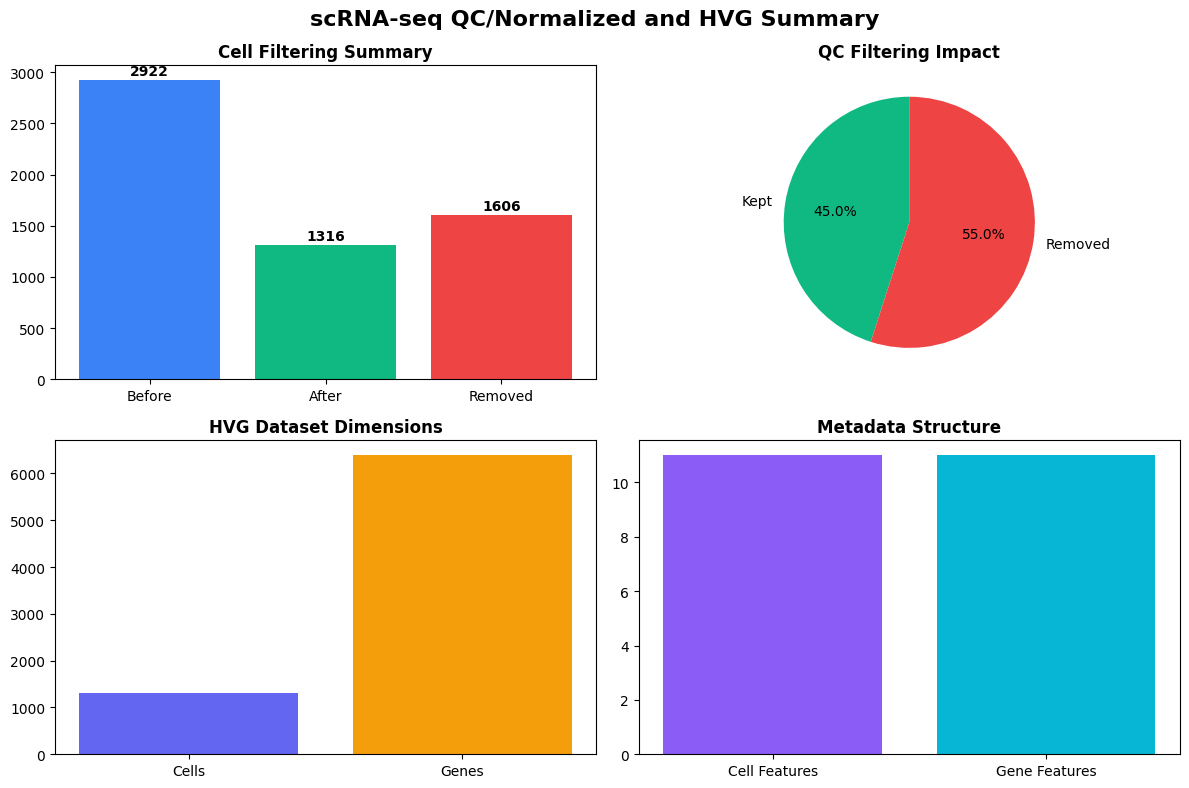

In [120]:
import matplotlib.pyplot as plt

# ==========================
# DATA
# ==========================
before = 2922
after = 1316
removed = before - after

removed_pct = (removed / before) * 100
kept_pct = 100 - removed_pct

hvg_cells = 1316
hvg_genes = 6389

# ==========================
# CREATE SUBPLOTS
# ==========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==========================
# 1. Cell Filtering Bar Chart
# ==========================
axes[0,0].bar(
    ["Before", "After", "Removed"],
    [before, after, removed],
    color=["#3B82F6", "#10B981", "#EF4444"]
)
axes[0,0].set_title("Cell Filtering Summary", fontweight="bold")

for i, v in enumerate([before, after, removed]):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontweight="bold")

# ==========================
# 2. QC Percentage Pie Chart
# ==========================
axes[0,1].pie(
    [kept_pct, removed_pct],
    labels=["Kept", "Removed"],
    autopct='%1.1f%%',
    colors=["#10B981", "#EF4444"],
    startangle=90
)
axes[0,1].set_title("QC Filtering Impact", fontweight="bold")

# ==========================
# 3. HVG Dimensions
# ==========================
axes[1,0].bar(
    ["Cells", "Genes"],
    [hvg_cells, hvg_genes],
    color=["#6366F1", "#F59E0B"]
)
axes[1,0].set_title("HVG Dataset Dimensions", fontweight="bold")

# ==========================
# 4. Metadata Overview
# ==========================
axes[1,1].bar(
    ["Cell Features", "Gene Features"],
    [11, 11],
    color=["#8B5CF6", "#06B6D4"]
)
axes[1,1].set_title("Metadata Structure", fontweight="bold")

# ==========================
# FINAL TOUCH
# ==========================
plt.suptitle("scRNA-seq QC/Normalized and HVG Summary", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig("final_qc_dashboard.png", dpi=300)
plt.show()

In [121]:
#PCA 

In [122]:
import scanpy as sc

sc.tl.pca(adata, svd_solver='arpack')

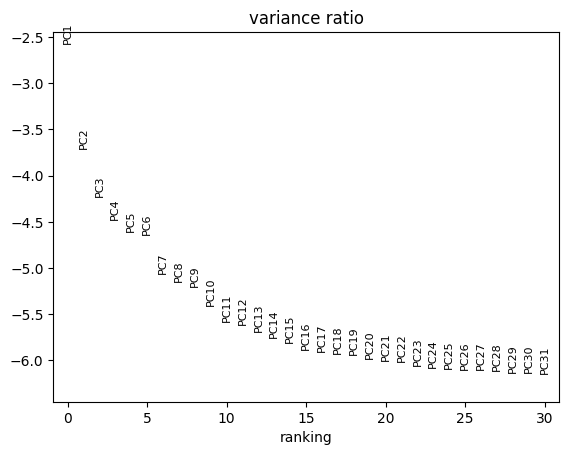

In [123]:
sc.pl.pca_variance_ratio(
    adata,
    log=True
)

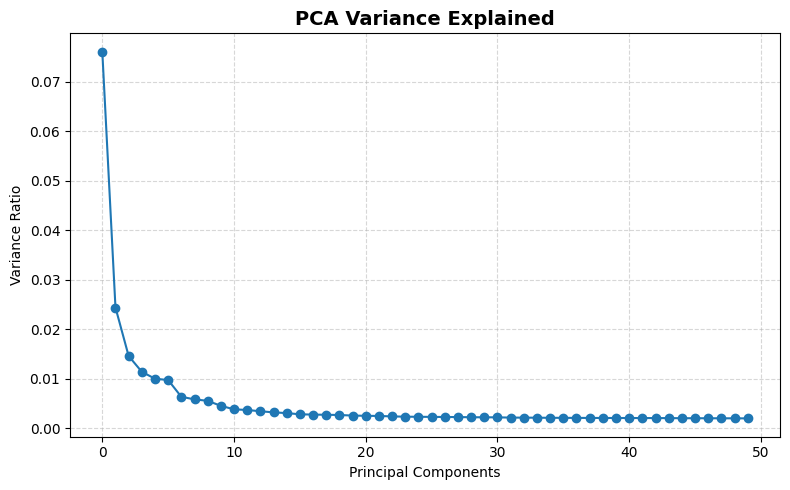

In [124]:
import matplotlib.pyplot as plt

# Extract variance ratio
variance_ratio = adata.uns['pca']['variance_ratio']

plt.figure(figsize=(8,5))

plt.plot(variance_ratio, marker='o', linestyle='-')
plt.title("PCA Variance Explained", fontsize=14, fontweight="bold")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("pca_variance_plot.png", dpi=300)
plt.show()

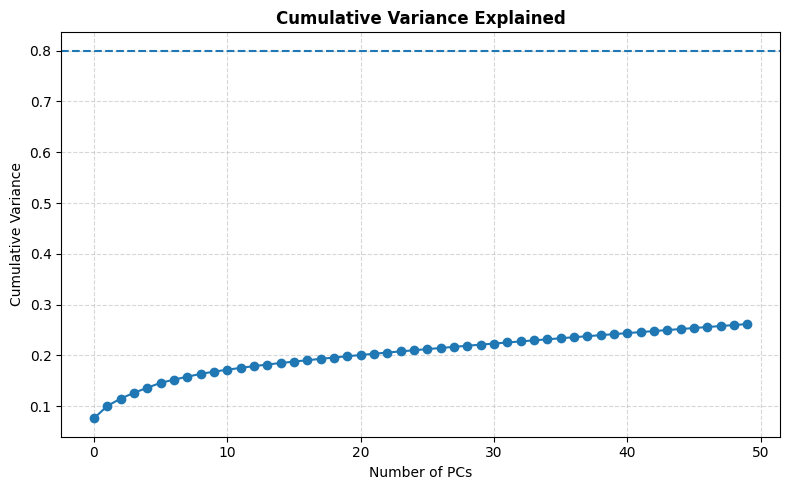

In [125]:
import numpy as np

cumulative_variance = np.cumsum(variance_ratio)

plt.figure(figsize=(8,5))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.8, linestyle='--')  # 80% threshold

plt.title("Cumulative Variance Explained", fontweight="bold")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative Variance")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("pca_cumulative_variance.png", dpi=300)
plt.show()